# Лабораторная работа №8

Тема: Web-приложение для демонстрации моделей машинного обучения.  
Цель: разработать простое web-приложение, позволяющее обучать модели машинного обучения, задавать гиперпараметры и отображать результаты работы моделей.

В работе используется датасет agriculture.csv, который применялся в предыдущих лабораторных работах.  
Решается задача классификации: предсказание признака Категория (`низкий`, `средний`, `высокий`).

В приложении реализовано:
- загрузка и предобработка данных;
- выбор модели классификации;
- настройка гиперпараметров;
- обучение модели;
- вывод метрик качества;
- построение матрицы ошибок;
- визуализация важности признаков для дерева решений и случайного леса.

## 1. Установка библиотек

In [1]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.7 MB/s eta 0:00:00


## 2. Проверка наличия файла `agriculture.csv`

In [2]:
import os

if os.path.exists('agriculture.csv'):
    print('Файл agriculture.csv найден.')
else:
    print('Файл agriculture.csv не найден. Загрузите его в рабочую область Colab.')

Файл agriculture.csv не найден. Загрузите его в рабочую область Colab.


## 3. Создание файла приложения `app.py`

In [3]:
app_code = '\nimport streamlit as st\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.preprocessing import OneHotEncoder, StandardScaler\n\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.tree import DecisionTreeClassifier\nfrom sklearn.ensemble import RandomForestClassifier\n\nfrom sklearn.metrics import (\n    accuracy_score,\n    f1_score,\n    classification_report,\n    ConfusionMatrixDisplay\n)\n\nst.set_page_config(page_title="ЛР №8: ML Web App", layout="wide")\n\nst.title("Лабораторная работа №8")\nst.subheader("Web-приложение для демонстрации моделей машинного обучения")\n\nst.markdown("""\nВ приложении решается задача классификации для датасета **agriculture.csv**.  \nЦелевая переменная — **Категория** (`низкий`, `средний`, `высокий`).\n""")\n\n@st.cache_data\ndef load_data(path):\n    df = pd.read_csv(path, sep=\';\', encoding=\'cp1251\')\n    df.columns = df.columns.str.strip()\n\n    for col in df.select_dtypes(include=\'object\').columns:\n        df[col] = df[col].astype(str).str.strip().str.lower()\n\n    df[\'Наименование вида сельхоз. продукции\'] = (\n        df[\'Наименование вида сельхоз. продукции\']\n        .str.replace(\', тыс. штук\', \'\', regex=False)\n    )\n\n    def convert_to_float(series):\n        series = series.astype(str).str.replace(\',\', \'.\', regex=False).str.strip()\n        return pd.to_numeric(series, errors=\'coerce\')\n\n    df[\'Показатель, тыс. ед.\'] = convert_to_float(df[\'Показатель, тыс. ед.\'])\n    df[\'Доля\'] = convert_to_float(df[\'Доля\'])\n    df[\'Темп роста, %\'] = convert_to_float(df[\'Темп роста, %\'])\n    df[\'Год\'] = pd.to_numeric(df[\'Год\'], errors=\'coerce\')\n\n    return df\n\ntry:\n    df = load_data(\'agriculture.csv\')\nexcept FileNotFoundError:\n    st.error("Файл agriculture.csv не найден. Загрузите файл в рабочую область Colab.")\n    st.stop()\n\nst.sidebar.header("Настройки модели")\n\nmodel_name = st.sidebar.selectbox(\n    "Выберите модель",\n    ["Логистическая регрессия", "Дерево решений", "Случайный лес"]\n)\n\ntest_size = st.sidebar.slider(\n    "Доля тестовой выборки",\n    min_value=0.1,\n    max_value=0.4,\n    value=0.2,\n    step=0.05\n)\n\nrandom_state = st.sidebar.number_input(\n    "random_state",\n    min_value=0,\n    max_value=1000,\n    value=42,\n    step=1\n)\n\nst.sidebar.markdown("---")\n\nif model_name == "Логистическая регрессия":\n    C = st.sidebar.slider("C", min_value=0.1, max_value=5.0, value=1.0, step=0.1)\n    max_iter = st.sidebar.slider("max_iter", min_value=500, max_value=5000, value=2000, step=500)\n\nelif model_name == "Дерево решений":\n    max_depth = st.sidebar.slider("max_depth", min_value=2, max_value=15, value=5, step=1)\n    min_samples_leaf = st.sidebar.slider("min_samples_leaf", min_value=1, max_value=10, value=1, step=1)\n\nelse:\n    n_estimators = st.sidebar.slider("n_estimators", min_value=50, max_value=500, value=200, step=50)\n    max_depth_rf = st.sidebar.slider("max_depth", min_value=2, max_value=20, value=8, step=1)\n    min_samples_leaf_rf = st.sidebar.slider("min_samples_leaf", min_value=1, max_value=10, value=2, step=1)\n\nst.header("1. Исходные данные")\n\ncol1, col2 = st.columns(2)\n\nwith col1:\n    st.write("Первые строки датасета:")\n    st.dataframe(df.head())\n\nwith col2:\n    st.write("Количество пропусков:")\n    st.dataframe(df.isna().sum().to_frame("Количество пропусков"))\n\nst.write("Размер датасета:", df.shape)\n\nst.header("2. Подготовка данных")\n\ntarget_map = {\'низкий\': 0, \'средний\': 1, \'высокий\': 2}\nreverse_target_map = {0: \'низкий\', 1: \'средний\', 2: \'высокий\'}\n\ndf[\'Категория_ord\'] = df[\'Категория\'].map(target_map)\n\nX = df.drop(columns=[\'Категория\', \'Категория_ord\'])\ny = df[\'Категория_ord\']\n\nnumeric_features = [\'Год\', \'Показатель, тыс. ед.\', \'Доля\', \'Темп роста, %\']\ncategorical_features = [\'Сектор\', \'Наименование вида сельхоз. продукции\']\n\nnumeric_transformer = Pipeline(steps=[\n    (\'imputer\', SimpleImputer(strategy=\'median\')),\n    (\'scaler\', StandardScaler())\n])\n\ntry:\n    categorical_transformer = Pipeline(steps=[\n        (\'imputer\', SimpleImputer(strategy=\'most_frequent\')),\n        (\'onehot\', OneHotEncoder(handle_unknown=\'ignore\', sparse_output=False))\n    ])\nexcept TypeError:\n    categorical_transformer = Pipeline(steps=[\n        (\'imputer\', SimpleImputer(strategy=\'most_frequent\')),\n        (\'onehot\', OneHotEncoder(handle_unknown=\'ignore\', sparse=False))\n    ])\n\npreprocessor = ColumnTransformer(transformers=[\n    (\'num\', numeric_transformer, numeric_features),\n    (\'cat\', categorical_transformer, categorical_features)\n])\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X,\n    y,\n    test_size=test_size,\n    random_state=random_state,\n    stratify=y\n)\n\nst.write("Размер обучающей выборки:", X_train.shape)\nst.write("Размер тестовой выборки:", X_test.shape)\n\nst.write("Распределение классов:")\nst.dataframe(y.value_counts().rename(index=reverse_target_map).to_frame("Количество"))\n\nst.header("3. Обучение модели")\n\nif model_name == "Логистическая регрессия":\n    model = LogisticRegression(C=C, max_iter=max_iter, random_state=random_state)\n\nelif model_name == "Дерево решений":\n    model = DecisionTreeClassifier(\n        max_depth=max_depth,\n        min_samples_leaf=min_samples_leaf,\n        random_state=random_state\n    )\n\nelse:\n    model = RandomForestClassifier(\n        n_estimators=n_estimators,\n        max_depth=max_depth_rf,\n        min_samples_leaf=min_samples_leaf_rf,\n        random_state=random_state,\n        n_jobs=-1\n    )\n\npipeline = Pipeline(steps=[\n    (\'preprocessor\', preprocessor),\n    (\'model\', model)\n])\n\npipeline.fit(X_train, y_train)\ny_pred = pipeline.predict(X_test)\n\naccuracy = accuracy_score(y_test, y_pred)\nf1_macro = f1_score(y_test, y_pred, average=\'macro\')\n\nmetric_col1, metric_col2 = st.columns(2)\n\nwith metric_col1:\n    st.metric("Accuracy", round(accuracy, 4))\n\nwith metric_col2:\n    st.metric("F1-macro", round(f1_macro, 4))\n\nst.header("4. Отчёт классификации")\n\nreport = classification_report(\n    y_test,\n    y_pred,\n    target_names=[\'низкий\', \'средний\', \'высокий\'],\n    output_dict=True,\n    zero_division=0\n)\n\nst.dataframe(pd.DataFrame(report).transpose())\n\nst.header("5. Матрица ошибок")\n\nfig, ax = plt.subplots(figsize=(6, 5))\nConfusionMatrixDisplay.from_predictions(\n    y_test,\n    y_pred,\n    display_labels=[\'низкий\', \'средний\', \'высокий\'],\n    ax=ax,\n    colorbar=False\n)\nax.set_title(f"Матрица ошибок: {model_name}")\nst.pyplot(fig)\n\nst.header("6. Важность признаков")\n\nif model_name in ["Дерево решений", "Случайный лес"]:\n    fitted_preprocessor = pipeline.named_steps[\'preprocessor\']\n    fitted_model = pipeline.named_steps[\'model\']\n\n    feature_names = fitted_preprocessor.get_feature_names_out()\n    importances = fitted_model.feature_importances_\n\n    feature_importance_df = pd.DataFrame({\n        \'Признак\': feature_names,\n        \'Важность\': importances\n    }).sort_values(by=\'Важность\', ascending=False)\n\n    st.write("Топ-15 наиболее важных признаков:")\n    st.dataframe(feature_importance_df.head(15))\n\n    top_features = feature_importance_df.head(15)\n\n    fig2, ax2 = plt.subplots(figsize=(10, 6))\n    ax2.barh(top_features[\'Признак\'][::-1], top_features[\'Важность\'][::-1])\n    ax2.set_title("Важность признаков")\n    ax2.set_xlabel("Важность")\n    ax2.set_ylabel("Признак")\n    st.pyplot(fig2)\n\nelse:\n    st.info("Для логистической регрессии в данном приложении график важности признаков не строится.")\n\nst.header("7. Вывод")\n\nst.markdown(f"""\nВ ходе работы была обучена модель **{model_name}** для решения задачи классификации по датасету `agriculture.csv`.  \nПеред обучением была выполнена предобработка данных: заполнение пропусков, кодирование категориальных признаков и масштабирование числовых признаков.  \nКачество модели оценивалось с помощью метрик **Accuracy** и **F1-macro**.\n\nПолученные значения:\n- Accuracy = **{accuracy:.4f}**;\n- F1-macro = **{f1_macro:.4f}**.\n\nМодель позволяет классифицировать объекты по категориям `низкий`, `средний`, `высокий`, а интерактивные настройки в боковой панели позволяют изменять гиперпараметры и сравнивать результаты.\n""")\n'

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('Файл app.py успешно создан.')


Файл app.py успешно создан.


## 4. Запуск приложения

In [4]:
# Установка cloudflared
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# Запуск Streamlit в фоне
!streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &

# Создание публичной ссылки через Cloudflare Tunnel
!./cloudflared tunnel --url http://localhost:8501

2026-05-21T06:43:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-21T06:43:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-21T06:43:45Z INF +--------------------------------------------------------------------------------------------+
2026-05-21T06:43:45Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-21T06:43:45Z INF |  https://racing-giant-necessity-emacs.trycloudflare.co

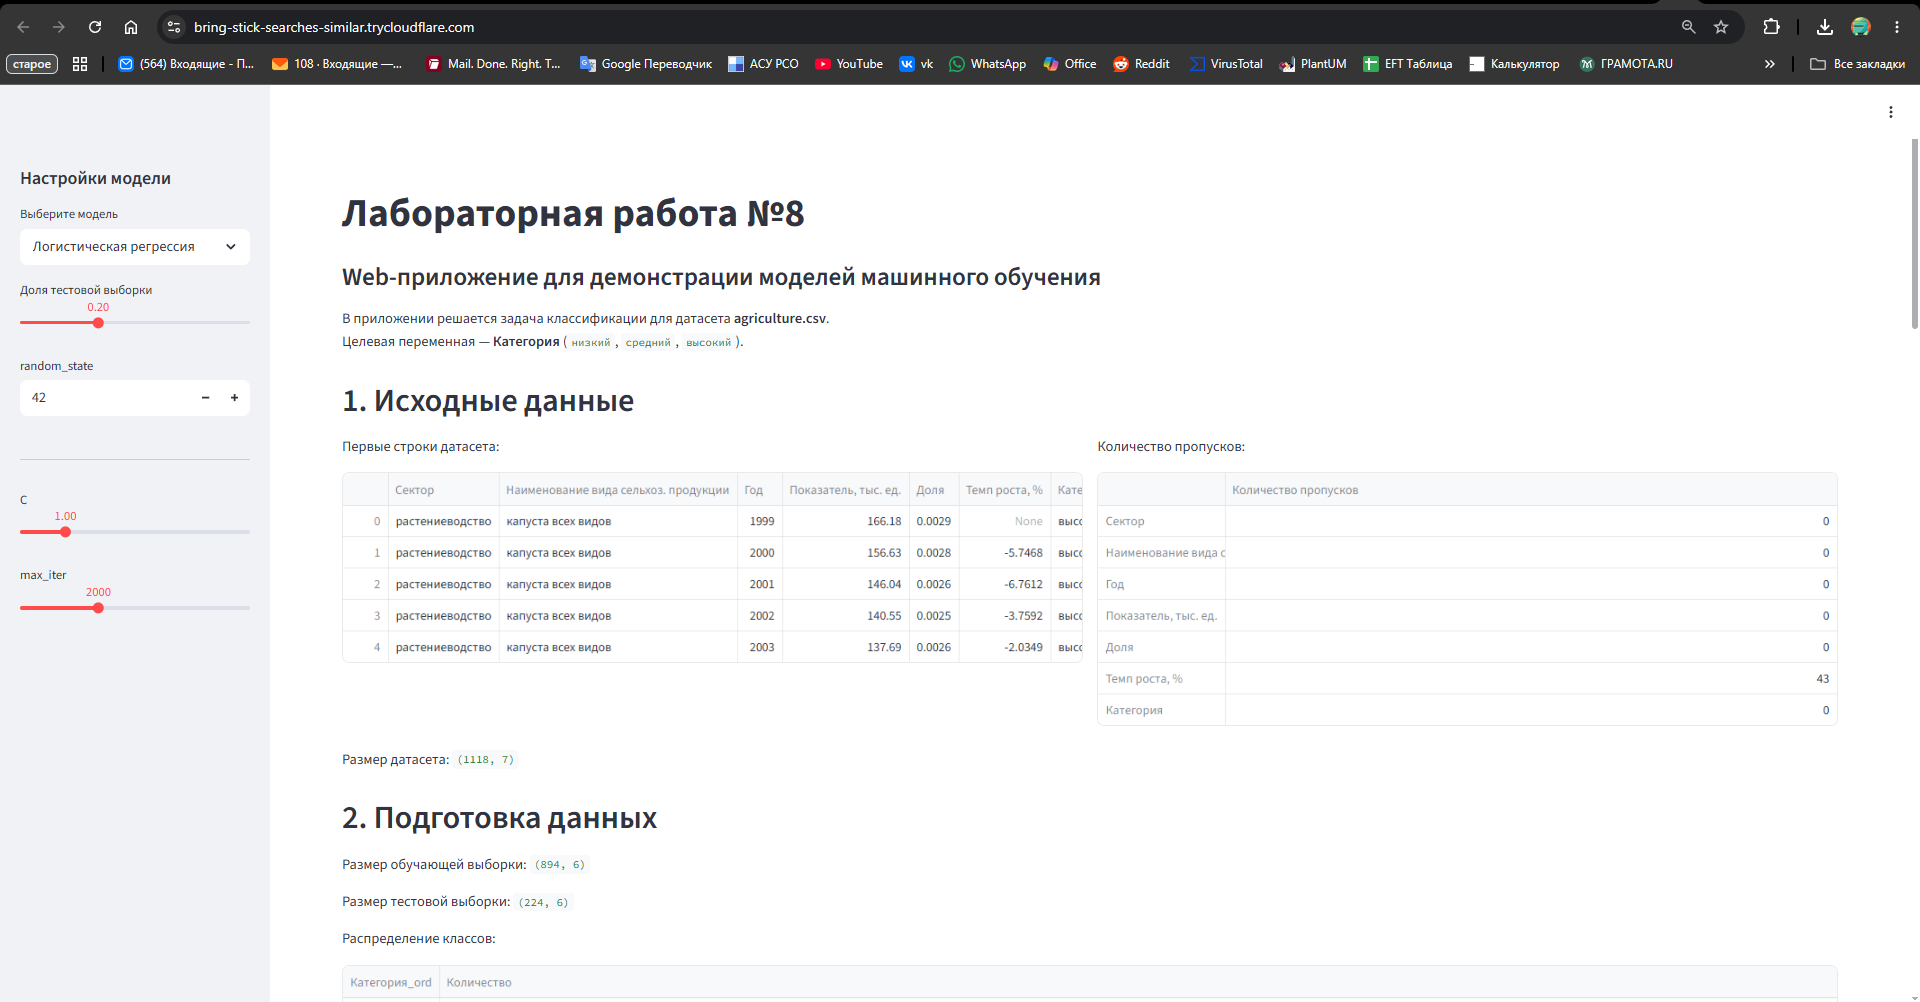

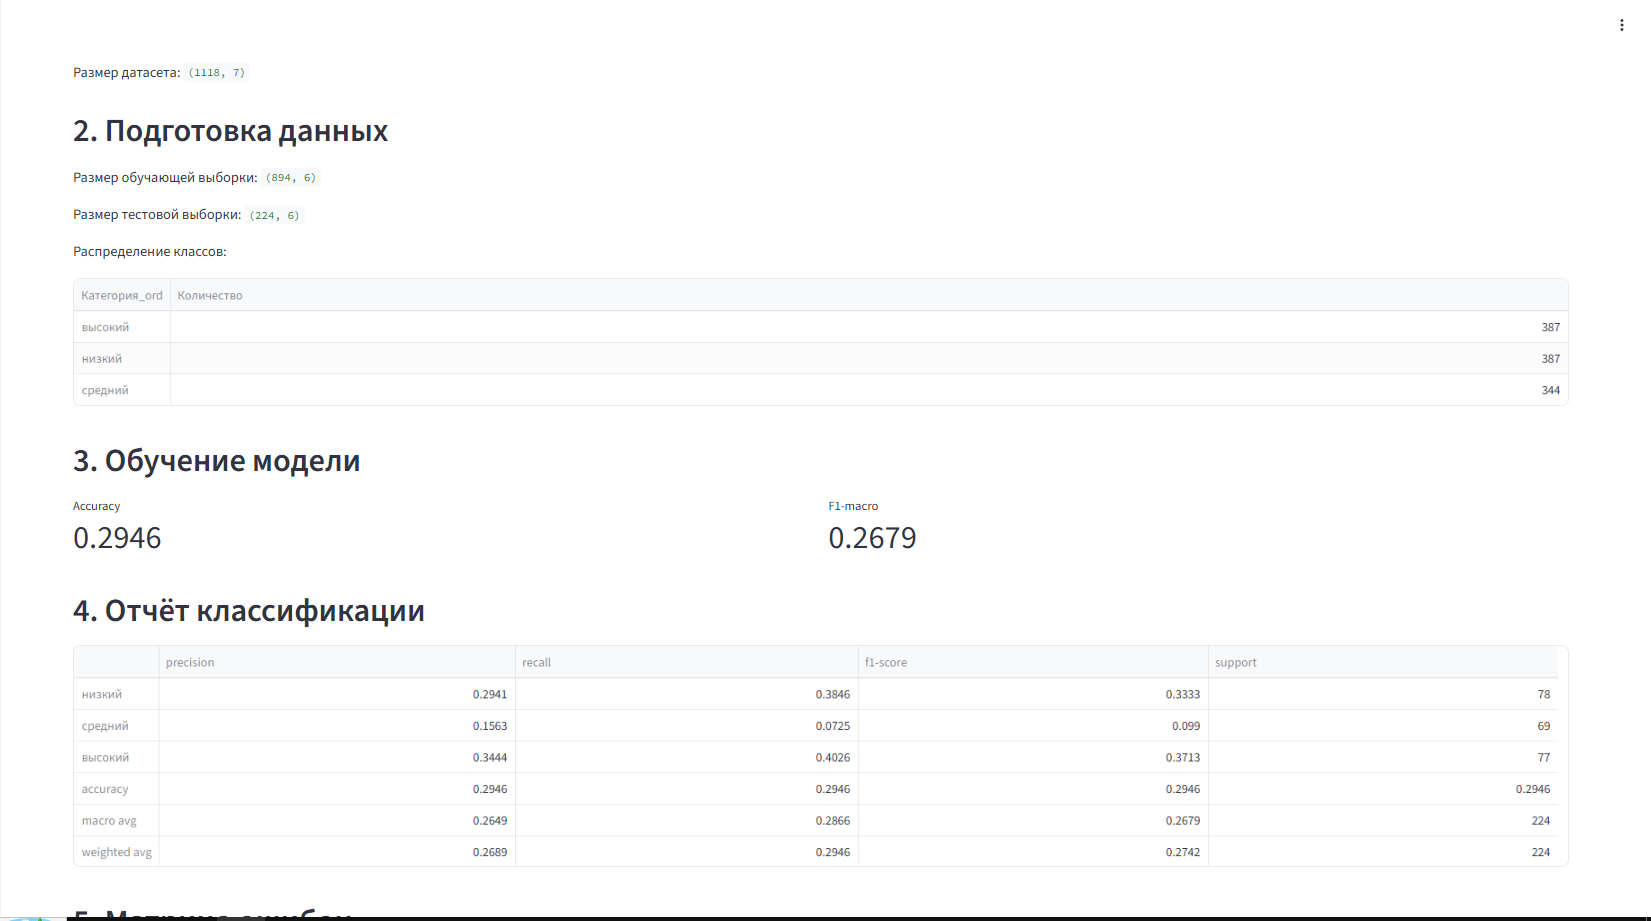

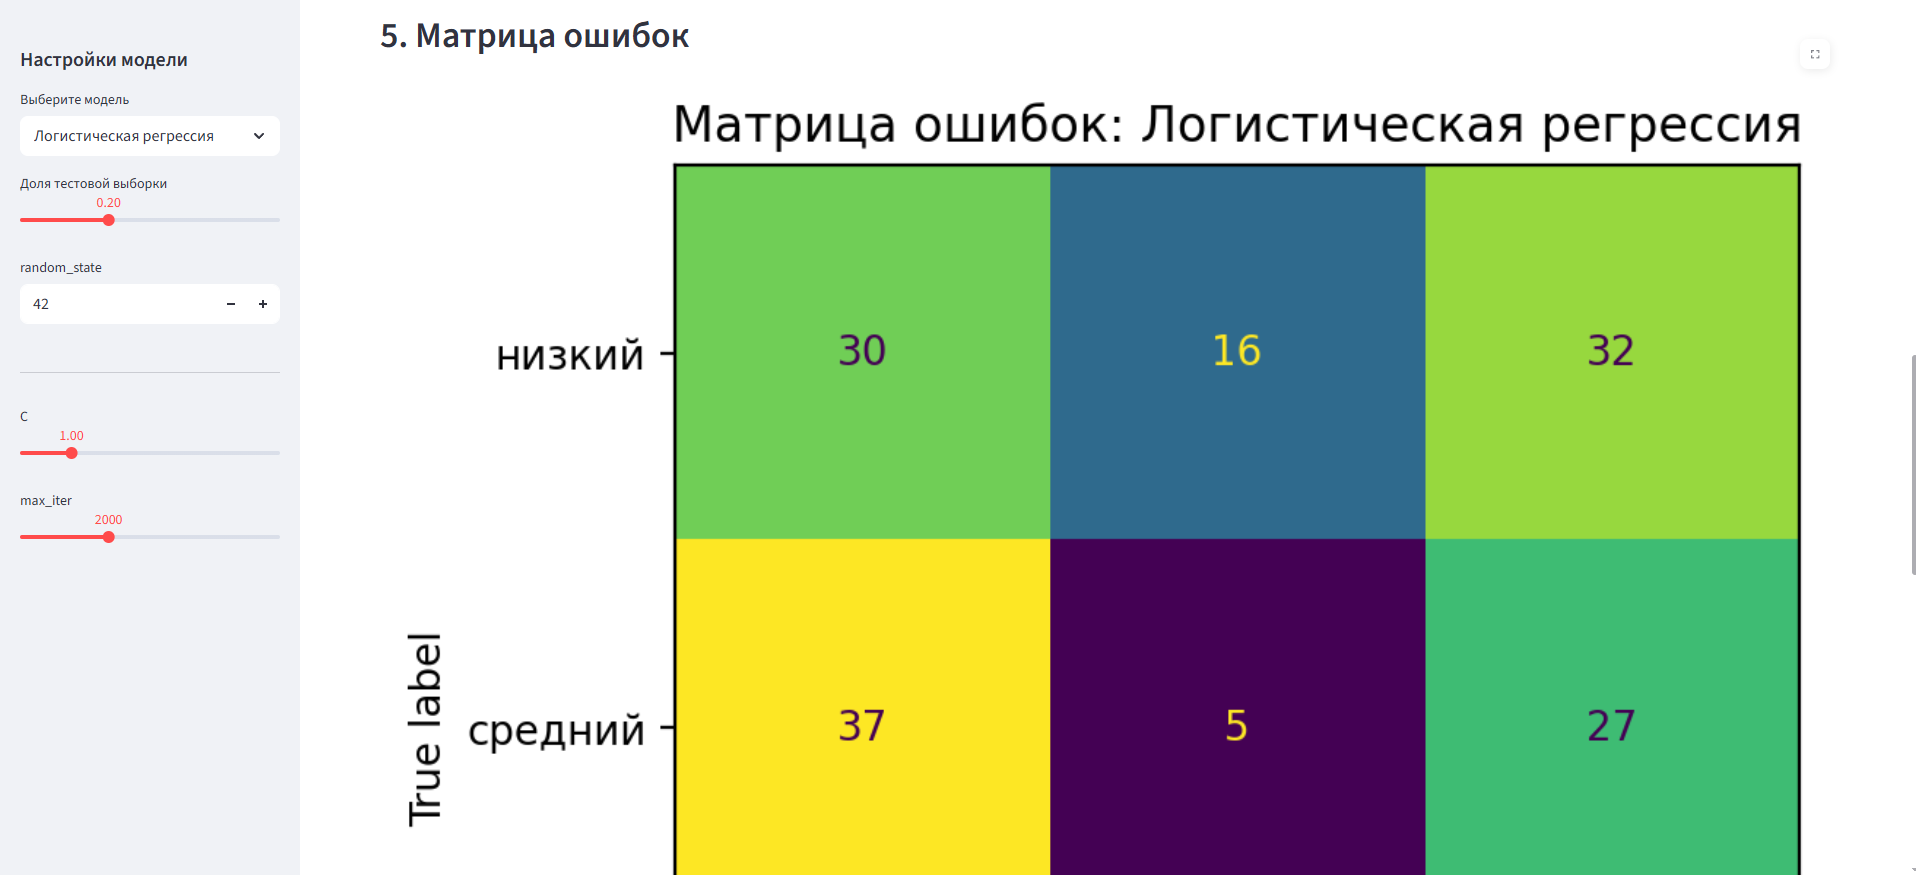

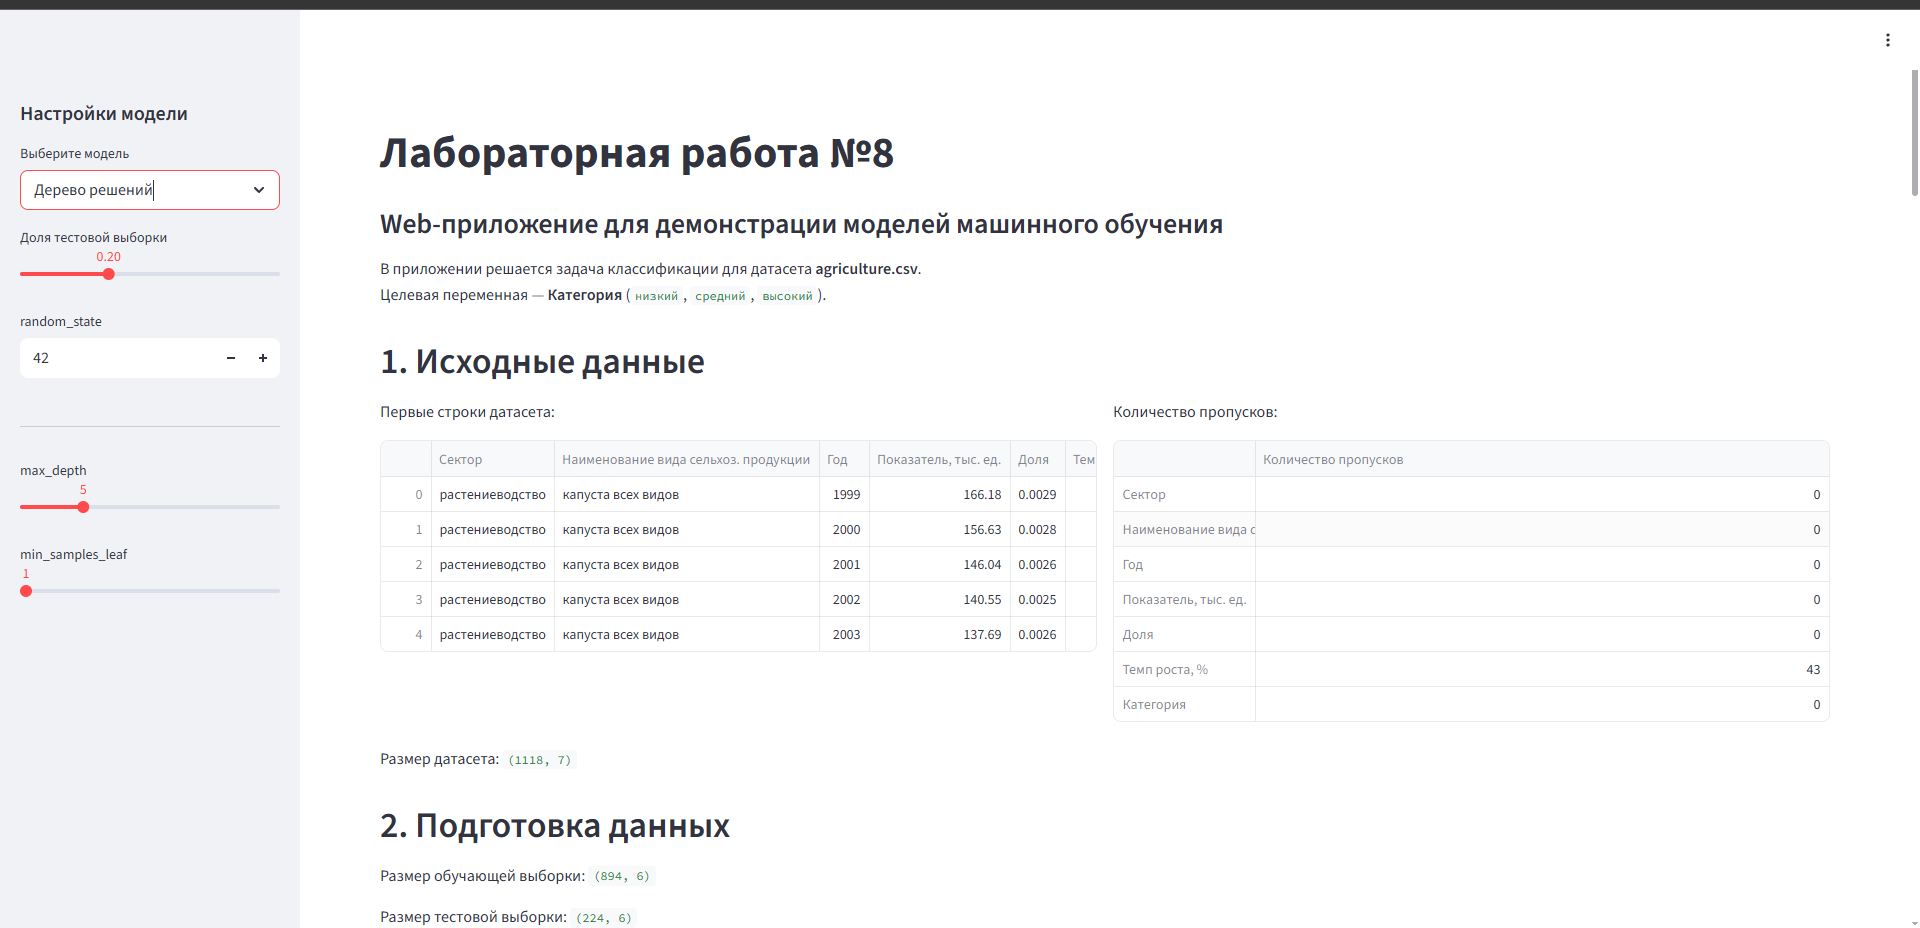

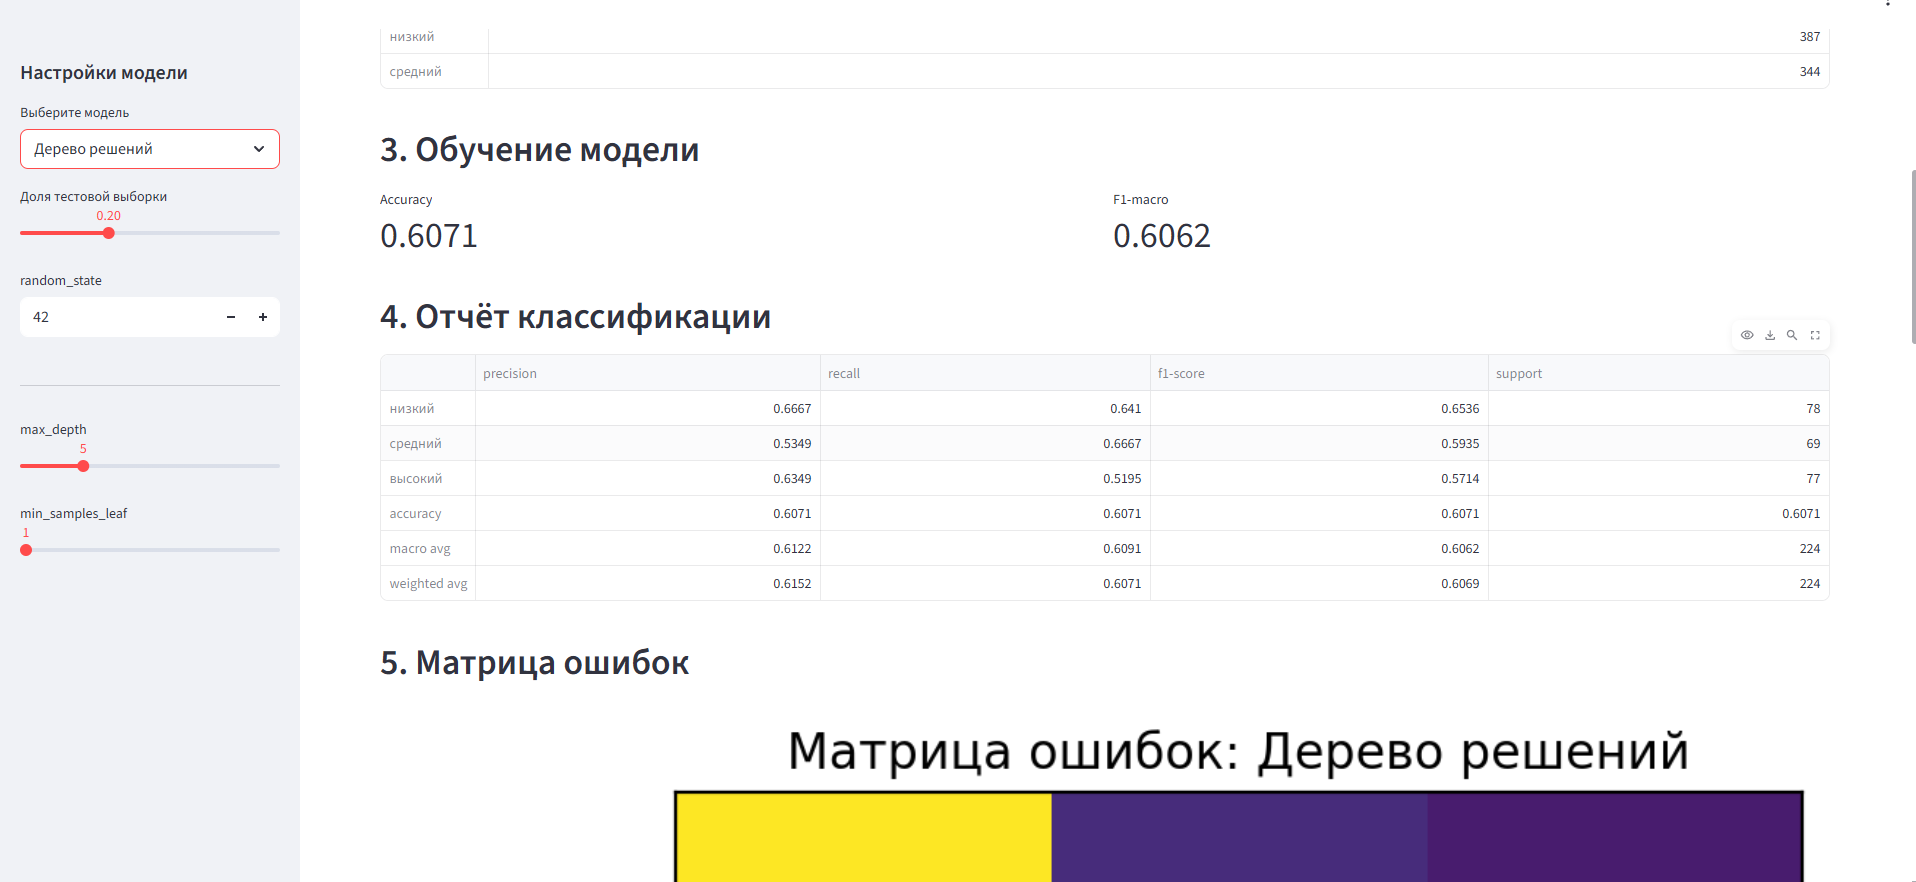

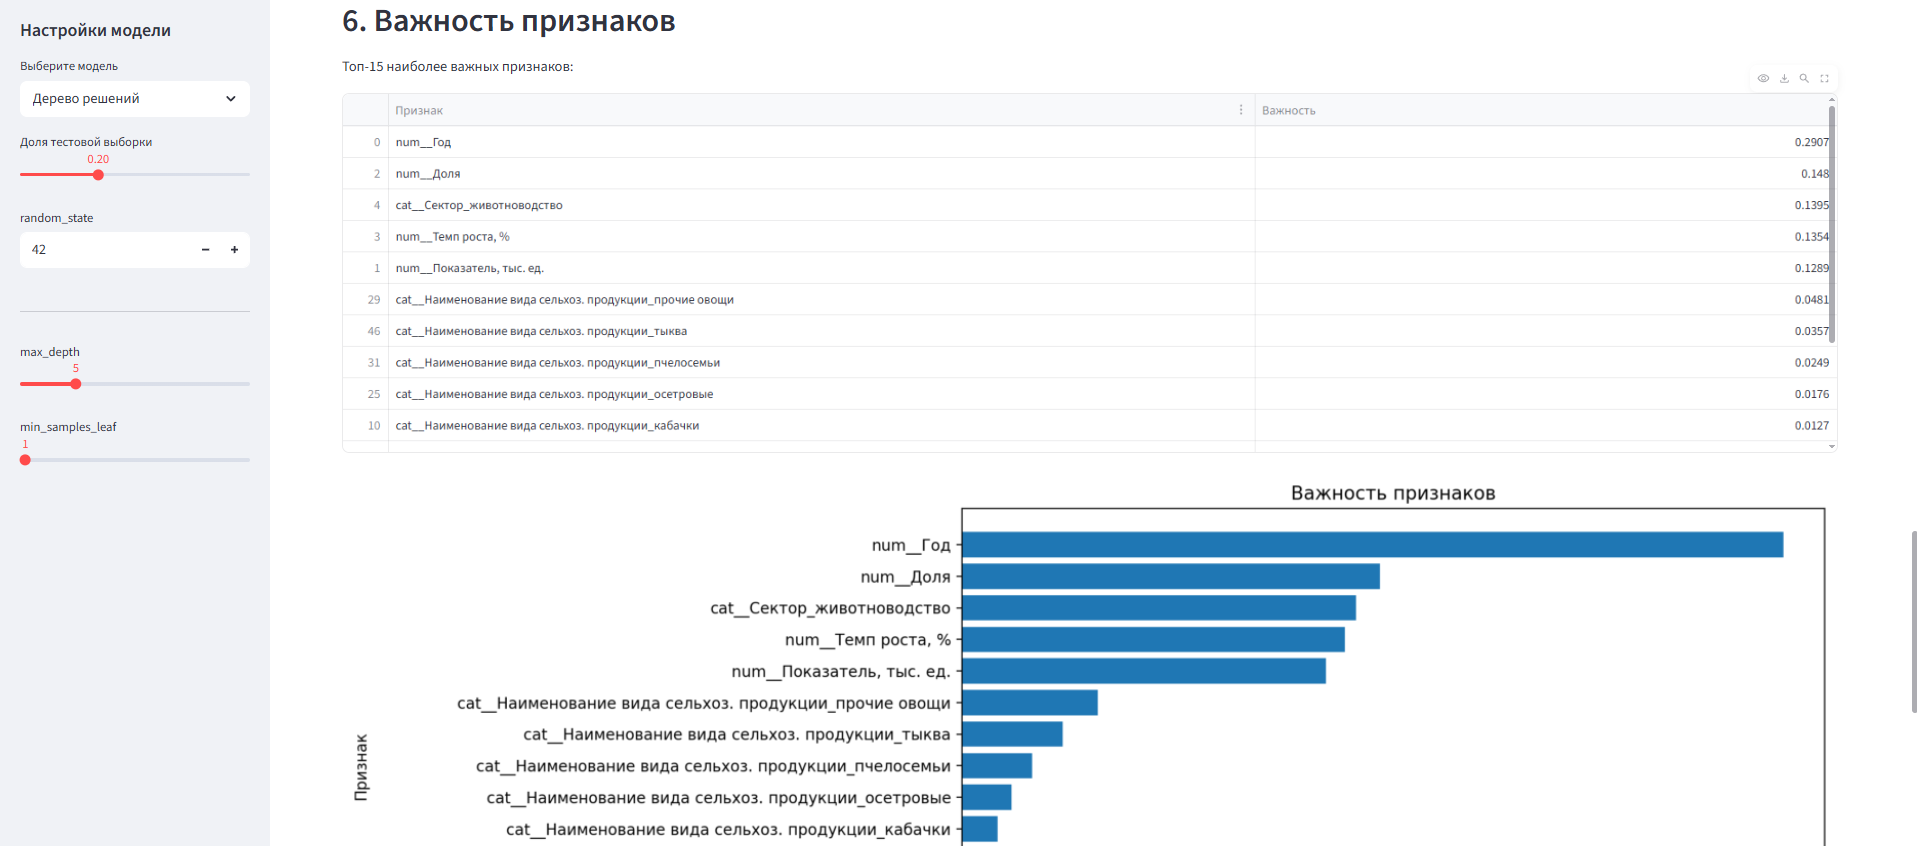

## Краткий вывод

В ходе лабораторной работы было разработано web-приложение на базе библиотеки Streamlit. Приложение позволяет загружать и обрабатывать данные, выбирать модель машинного обучения, изменять гиперпараметры, обучать модель и анализировать результаты классификации. Для оценки качества используются метрики Accuracy и F1-macro, а также матрица ошибок. Для моделей на основе деревьев дополнительно отображается важность признаков.